In [ ]:
import xarray as xr
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from shapely import contains_xy

In [9]:
def point_in_polygon(lon, lat, polygon):
    point = Point(lon, lat)
    return polygon.contains(point)

In [10]:
# Define a transformation to ensure the polygon's CRS matches
def transform_polygon(polygon, src_crs='epsg:4326', tgt_crs='epsg:4326'):
    # Transform the polygon to match the DataArray CRS if needed
    proj = pyproj.Transformer.from_proj(pyproj.Proj(src_crs), pyproj.Proj(tgt_crs), always_xy=True)
    return transform(lambda x, y: proj.transform(x, y), polygon)

In [14]:
file='./Cuencas/NAEast.csv'
df=pd.read_csv(file)

In [15]:
demPolygon = Polygon(np.column_stack((df.lon, df.lat)))

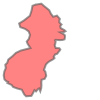

In [16]:
demPolygon

In [17]:
demPolygon_transformed = transform_polygon(demPolygon)

In [18]:
step = 1
longitude_space = np.arange(-180, 180 + step, step, dtype = float)
latitude_space = np.arange(-90, 90 + step, step, dtype = float)
lon_grid, lat_grid = np.meshgrid(longitude_space, latitude_space)


In [91]:
filesA = {'./Cuencas/NAEast.csv':1,
'./Cuencas/NAWest.csv':2,
'./Cuencas/NACaribe.csv':3,
'./Cuencas/SAEast.csv':4,
'./Cuencas/SAWestNorth.csv':5,
'./Cuencas/SAEastNamibia.csv':6,
'./Cuencas/SAWestMalvinas.csv':7,
'./Cuencas/SouthAfrica.csv':8,
'./Cuencas/SACentralAntartica.csv':10,
'./Cuencas/SPEastAntartica.csv':11}

filesI={'./Cuencas/EastMadagascar.csv':21,
'./Cuencas/SouthMadagascar.csv':22,
'./Cuencas/NIWest.csv':23,
'./Cuencas/NICentral.csv':24,
'./Cuencas/NICentralEast.csv':25,
'./Cuencas/NIEast.csv':26,
#'./Cuencas/SACentralAntartica.csv',
#'./Cuencas/SouthAfrica.csv':27,
'./Cuencas/SouthAustralia.csv':27,
'./Cuencas/SIEastAntartica.csv':28}

filesP={'./Cuencas/NPWest.csv':31,
'./Cuencas/NPEast.csv':32,
'./Cuencas/NPEastEast.csv':33,
'./Cuencas/NPCentral.csv':34,
'./Cuencas/SPCentral.csv':35,
'./Cuencas/SPWestCentral.csv':36,
'./Cuencas/SPEastAustralia.csv':37,
#'./Cuencas/SIEastAntartica.csv':,
'./Cuencas/SPWest.csv':38,
'./Cuencas/SPEastNorth.csv':39,
'./Cuencas/SPEastChile.csv':40,
#'./Cuencas/SouthAustralia.csv':21,
#'./Cuencas/SPEastAntartica.csv':21
}


In [94]:
Z = np.zeros(lon_grid.shape)
Z=Z-100

for file, vZ in filesA.items():
    df=pd.read_csv(file)
    demPolygon = Polygon(np.column_stack((df.lon, df.lat)))
    mask = contains_xy(demPolygon, lon_grid, lat_grid)
    Z[mask] = vZ

for file, vZ in filesA.items():
    df=pd.read_csv(file)
    demPolygon = Polygon(np.column_stack((df.lon-360, df.lat)))
    mask = contains_xy(demPolygon, lon_grid, lat_grid)
    Z[mask] = vZ


for file, vZ in filesI.items():
    df=pd.read_csv(file)
    demPolygon = Polygon(np.column_stack((df.lon, df.lat)))
    mask = contains_xy(demPolygon, lon_grid, lat_grid)
    Z[mask] = vZ    

for file, vZ in filesP.items():
    df=pd.read_csv(file)
    demPolygon = Polygon(np.column_stack((df.lon-360, df.lat)))
    mask = contains_xy(demPolygon, lon_grid, lat_grid)
    Z[mask] = vZ       

for file, vZ in filesP.items():
    df=pd.read_csv(file)
    demPolygon = Polygon(np.column_stack((df.lon, df.lat)))
    mask = contains_xy(demPolygon, lon_grid, lat_grid)
    Z[mask] = vZ   

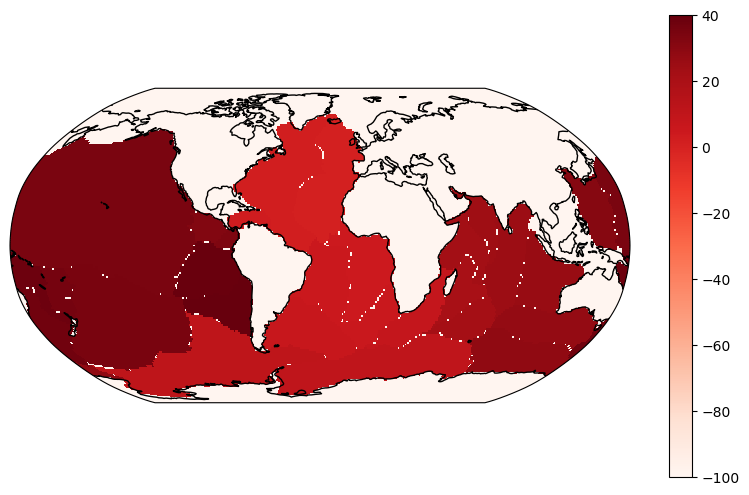

In [95]:
fig, ax = plt.subplots(figsize=(10,6),
    subplot_kw={'projection': ccrs.Robinson(central_longitude=-30)})

ax.set_global()
ax.coastlines()
pcm = ax.pcolormesh(lon_grid, lat_grid, Z,transform=ccrs.PlateCarree(),
                    cmap='Reds')

ax.add_feature(cfeature.LAND, facecolor='white')

cbar = fig.colorbar(pcm, ax=ax)



(array([[ 47.,   0.,  18., ...,   0.,  94.,  22.],
        [ 46.,   0.,  18., ...,   0., 100.,  17.],
        [ 46.,   0.,  17., ...,   0., 109.,   9.],
        ...,
        [ 47.,   0.,  18., ...,   0.,  91.,  25.],
        [ 47.,   0.,  18., ...,   0.,  92.,  24.],
        [ 47.,   0.,  18., ...,   0.,  94.,  22.]], shape=(361, 10)),
 array([ 0.,  4.,  8., 12., 16., 20., 24., 28., 32., 36., 40.]),
 <a list of 361 BarContainer objects>)

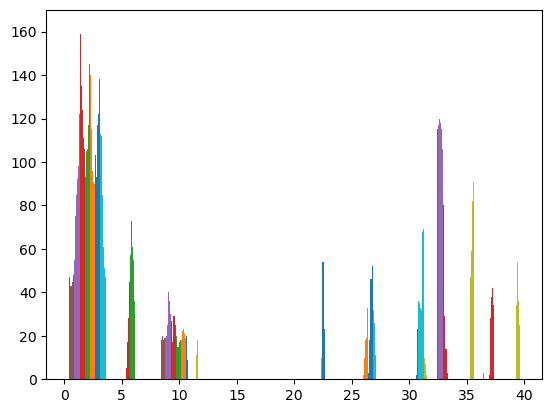

In [83]:
plt.hist(Z)